<a href="https://www.kaggle.com/code/hasnainaliasghar941/fashion-mnist-model-training-ann?scriptVersionId=350993458" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


# Basic Imports

In [2]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## GPU Check

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [4]:
torch.manual_seed(42)

In [5]:
df = pd.read_csv("/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


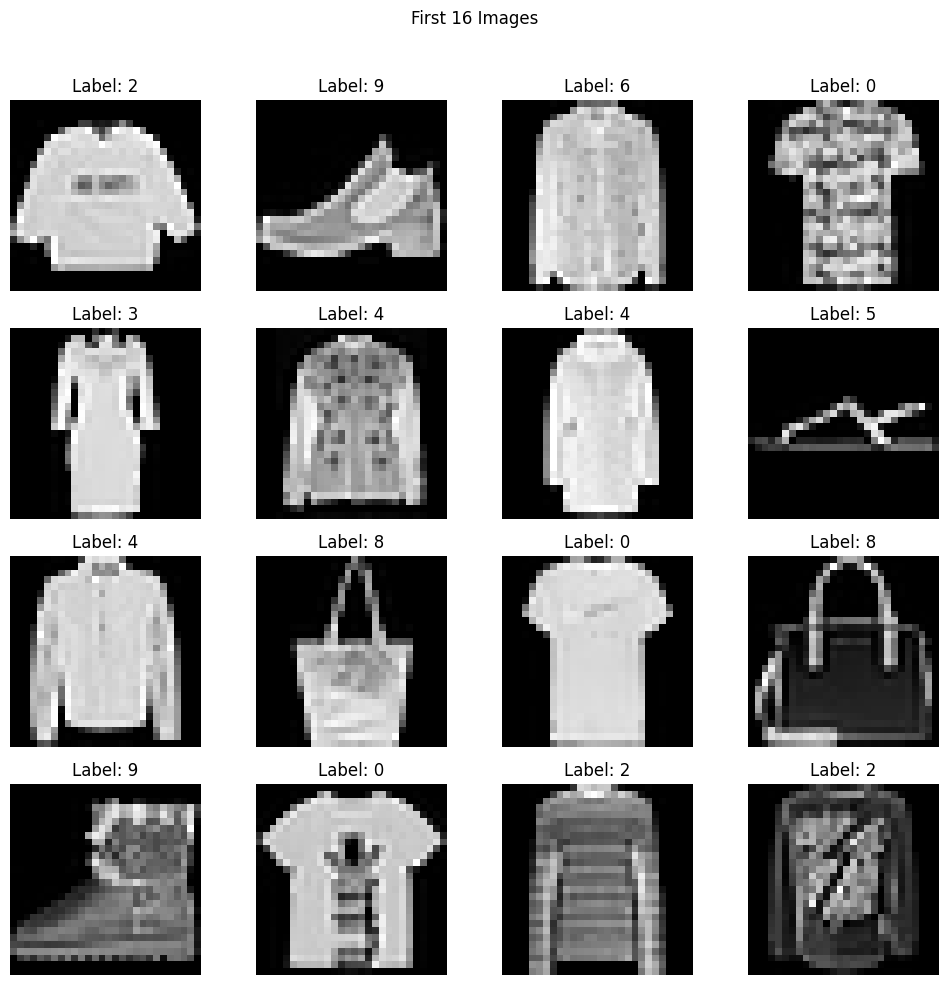

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images")

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img, cmap="gray")
  ax.axis("off")
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout(rect = [0,0,1,0.96])
plt.show()

In [7]:
X = df.drop(columns = ["label"])
y = df["label"]

## Teain Test Split

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y, random_state = 42, test_size = 0.2)

In [9]:
X_train.shape

(48000, 784)

In [10]:
X_train = X_train/255.0
X_test = X_test/255.0

In [11]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
48572,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
38696,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
13611,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
35213,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
31766,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.003922,0.0,...,0.000000,0.000000,0.003922,0.000000,0.043137,0.145098,0.023529,0.000000,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54343,0.0,0.0,0.0,0.0,0.0,0.011765,0.027451,0.000000,0.000000,0.0,...,0.682353,0.705882,0.768627,0.921569,0.000000,0.000000,1.000000,0.898039,0.65098,0.0
38158,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
860,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
15795,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.007843,0.000000,0.0,...,0.368627,0.290196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0


In [12]:
#Custom DatasetClass
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features.to_numpy(), dtype = torch.float32)
    self.labels = torch.tensor(labels.to_numpy(), dtype= torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

In [13]:
print(CustomDataset)

<class '__main__.CustomDataset'>


In [14]:
type(X_train)

pandas.core.frame.DataFrame

In [15]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [16]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [17]:
len(train_loader)

1500

In [18]:
#define nn class
class MyNN(nn.Module):

  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.model(x)


In [19]:
#set of learning rate and epochs
epochs = 100
learning_rate = 0.1

In [20]:
model = MyNN(X_train.shape[1])
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [21]:
#training loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    #Customizing to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    
    #forward pass
    outputs = model(batch_features)
    
    #calculate loss
    loss = criterion(outputs, batch_labels)
    optimizer.zero_grad()
    #back propagation
    loss.backward()
    
    #update grads
    optimizer.step()
    
    total_epoch_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_epoch_loss/len(train_loader)}")

Epoch 1, Loss: 0.6352872474888961
Epoch 2, Loss: 0.4304986953884363
Epoch 3, Loss: 0.3861262078657746
Epoch 4, Loss: 0.3584607255011797
Epoch 5, Loss: 0.3376494748592377
Epoch 6, Loss: 0.32276468626906474
Epoch 7, Loss: 0.3078539018382629
Epoch 8, Loss: 0.2949818898836772
Epoch 9, Loss: 0.2854692505300045
Epoch 10, Loss: 0.27467058210571604
Epoch 11, Loss: 0.26830569267148774
Epoch 12, Loss: 0.2581421597401301
Epoch 13, Loss: 0.24940819991752505
Epoch 14, Loss: 0.24444738873218497
Epoch 15, Loss: 0.2385919222868979
Epoch 16, Loss: 0.23155899402375021
Epoch 17, Loss: 0.22562562982489665
Epoch 18, Loss: 0.2202964697740972
Epoch 19, Loss: 0.21206334652379155
Epoch 20, Loss: 0.20960091769819458
Epoch 21, Loss: 0.20624992956593632
Epoch 22, Loss: 0.19986103242821993
Epoch 23, Loss: 0.1953041393881043
Epoch 24, Loss: 0.19312163671137145
Epoch 25, Loss: 0.18764107141271233
Epoch 26, Loss: 0.18366442496639987
Epoch 27, Loss: 0.18018299543857574
Epoch 28, Loss: 0.17326497477230926
Epoch 29, Los

In [22]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [23]:
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    _, predicted = torch.max(outputs.data, 1)
    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 88.98%
